# EURO-CORDEX

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
import rasterio
import xarray
import affine
import matplotlib

Open an example

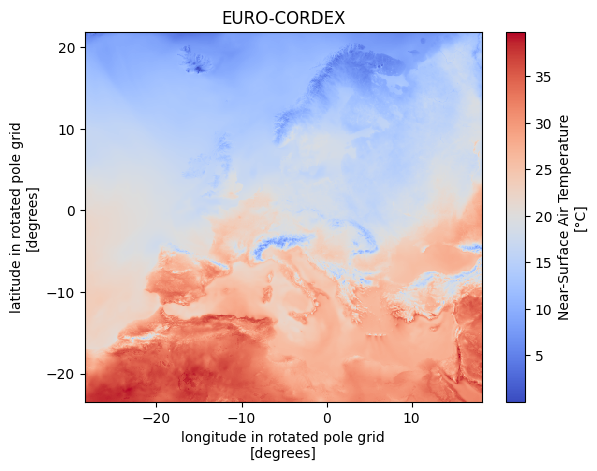

In [2]:
cordex = xarray.open_mfdataset('/home/tomas/ctu/current/rci_data/climate/CORDEX/tas/tas_EUR-11_ECMWF-ERAINT_evaluation_r1i1p1_GERICS-REMO2015_v1_day_*.nc', decode_coords="all")
cordex = cordex["tas"]

DATE = '2005-8-18'

cordex = cordex.sel(time=DATE[:4])
cordex -= 273.15
cordex.attrs['units'] = '°C'

fig, ax = plt.subplots(ncols=1, rasterized=True)
cordex.sel(time = DATE).plot(ax = ax, cmap="coolwarm")
ax.set_title('EURO-CORDEX')
plt.show()
fig.savefig('images/cordex.pdf', bbox_inches='tight', dpi=300)

Make reprojection into ReKIS CRS

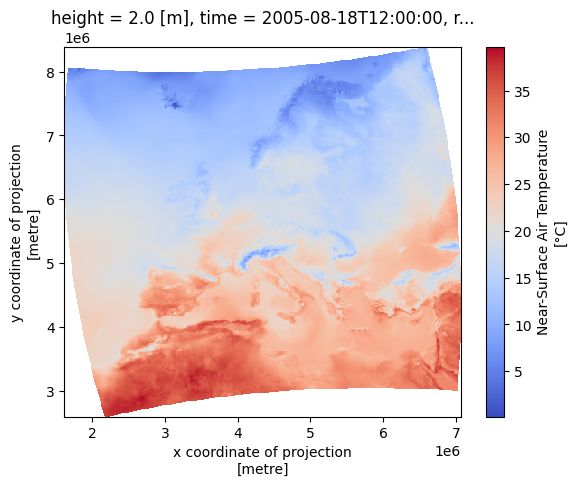

In [3]:
cordex = cordex.rio.reproject(
    dst_crs="EPSG:31468",
    resampling=rasterio.enums.Resampling.average,
)
cordex.sel(time=DATE).plot(cmap='coolwarm')
plt.show()

Load ReKIS and obtain bounds in the EPSG:31468

In [4]:
CLIMATE_VARIABLE = 'TM'
FILE_PATH = f'/home/tomas/ctu/current/rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/{CLIMATE_VARIABLE}/{CLIMATE_VARIABLE}_*.nc'

rekis = xr.open_mfdataset(FILE_PATH, decode_coords="all")
rekis = rekis[CLIMATE_VARIABLE]
rekis = rekis.rio.set_spatial_dims(x_dim="easting", y_dim="northing")
rekis = rekis.rio.write_crs("EPSG:31468")
rekis = rekis.isel(easting=slice(0, 400), northing=slice(0, 400))
rekis = rekis.sel(time=DATE[:4])
rekis = rekis.rio.set_spatial_dims(x_dim="easting", y_dim="northing")

bounds = rekis.rio.bounds()
print(bounds)

(4335000.0, 5555000.0, 4735000.0, 5955000.0)


Visualize pure EURO-CORDEX on the area of ReKIS

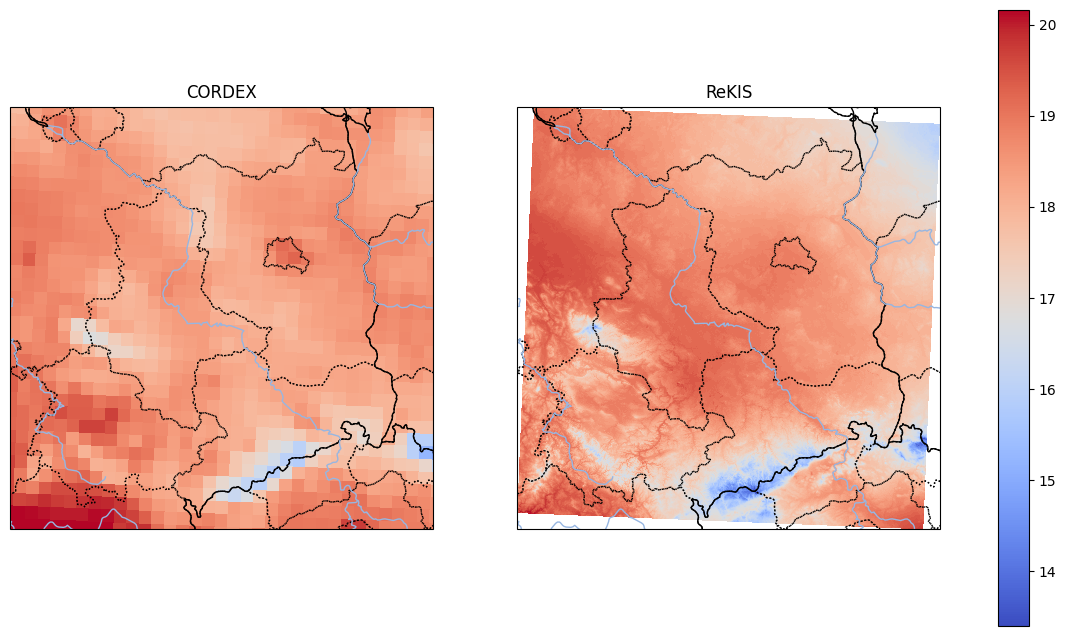

In [5]:
fig, axs = plt.subplots(ncols=2, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (15, 8))

cordex_in_rekis_region = cordex.sel(time=DATE, y = slice(bounds[3], bounds[1]), x = slice(bounds[0], bounds[2]))

vmin = min(cordex_in_rekis_region.min().values, rekis.sel(time=DATE).min().values)
vmax = max(cordex_in_rekis_region.max().values, rekis.sel(time=DATE).max().values)

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex.sel(time=DATE).plot(
    ax=axs[0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[0].set_extent(
    [bounds[0], bounds[2], bounds[1], bounds[3]],  # left, right, bottom, top
    crs=cartopy.crs.epsg(31468)
)

axs[0].set_title('CORDEX')

rekis.sel(time=DATE).plot(
    ax=axs[1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1].set_title('ReKIS')

fig.colorbar(im, ax = axs)

for ax in axs:
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES, linestyle=":")
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)
plt.show()

Modify both to obtain the same resolution in the matching area with same EPSG.

In [6]:
cordex_reprojected = cordex.rio.reproject(
        dst_crs="EPSG:31468",
        transform=affine.Affine(16000.0, 0.0, 4335000.0, 0.0, -16000.0, 5955000.0),
        shape=(400 // 16, 400 // 16),
        resampling=rasterio.enums.Resampling.average
)

rekis_upscaled = rekis.rio.reproject(
        dst_crs="EPSG:31468",
        resolution=(16_000, 16_000),
        resampling=rasterio.enums.Resampling.average
)

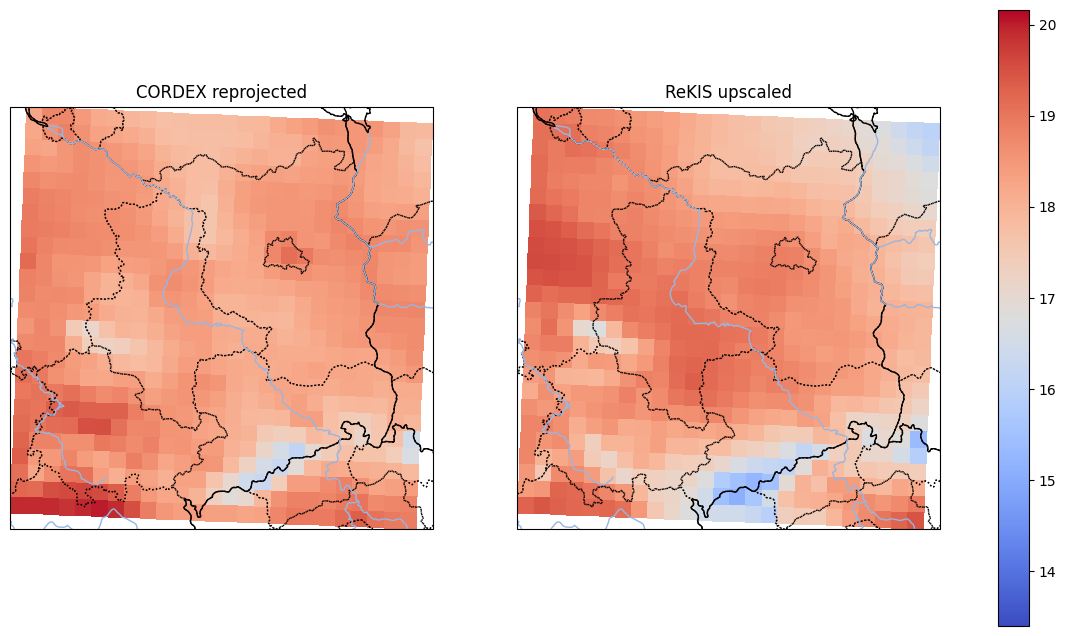

In [7]:
fig, axs = plt.subplots(ncols=2, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (15, 8))

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex_reprojected.sel(time=DATE).plot(
    ax=axs[0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[0].set_title('CORDEX reprojected')

rekis_upscaled.sel(time=DATE).plot(
    ax=axs[1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1].set_title('ReKIS upscaled')

fig.colorbar(im, ax = axs)

for ax in axs:
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES, linestyle=":")
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)
plt.show()

## Downscaled

Load downscaled version, which is an output of notebook `downscale_cordex`

In [9]:
cordex_downscaled = xr.open_mfdataset('downscaled/*.nc', decode_coords="all")
cordex_downscaled = cordex_downscaled["tas"]

cordex_downscaled = cordex_downscaled.sel(time=DATE[:4])

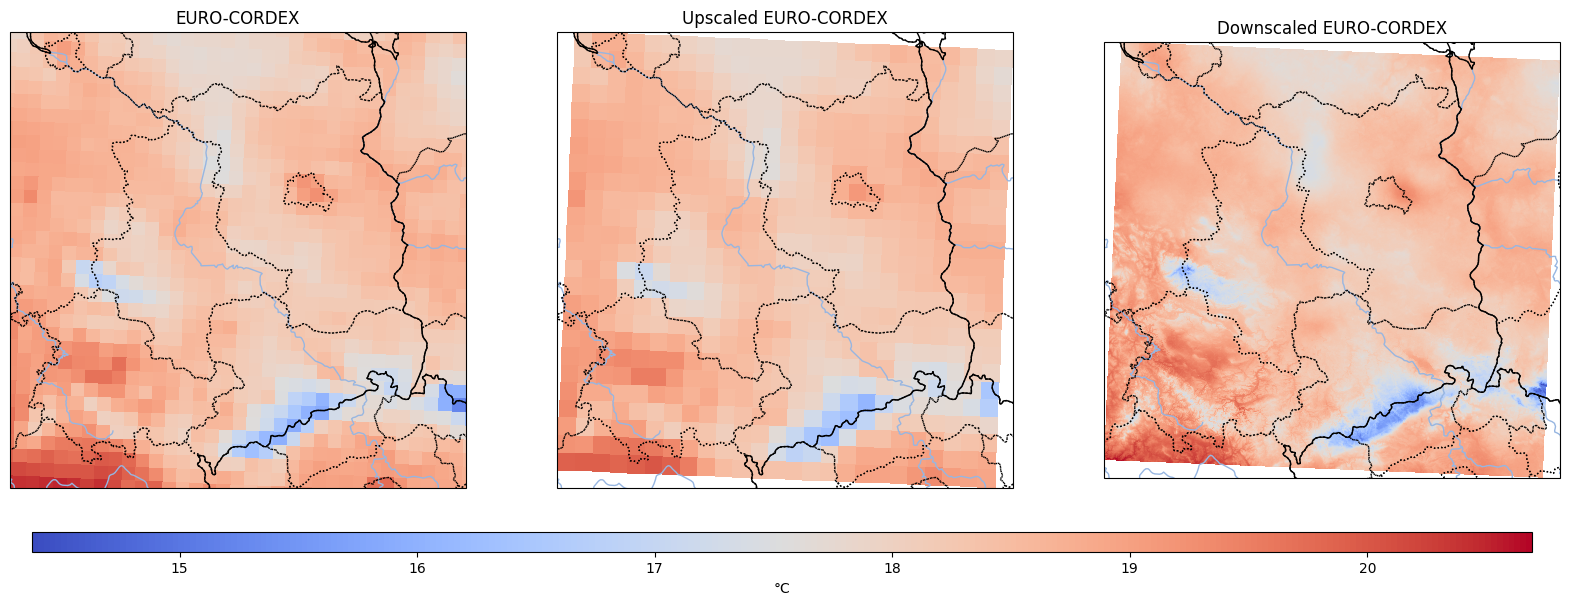

In [10]:
fig, axs = plt.subplots(ncols=3, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (20, 8), rasterized=True)

cordex_reprojected_in_rekis_region = cordex_reprojected.sel(time=DATE, y = slice(bounds[3], bounds[1]), x = slice(bounds[0], bounds[2]))

vmin = min(cordex_reprojected_in_rekis_region.min().values, cordex_in_rekis_region.min().values, cordex_downscaled.sel(time=DATE).min().values)
vmax = max(cordex_reprojected_in_rekis_region.max().values, cordex_in_rekis_region.max().values, cordex_downscaled.sel(time=DATE).max().values)

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex.sel(time=DATE).plot(
    ax=axs[0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)


axs[0].set_extent(
    [bounds[0], bounds[2], bounds[1], bounds[3]],  # left, right, bottom, top
    crs=cartopy.crs.epsg(31468)
)
axs[0].set_title('EURO-CORDEX')

cordex_reprojected.sel(time=DATE).plot(
    ax=axs[1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1].set_title('Upscaled EURO-CORDEX')

cordex_downscaled.sel(time=DATE).plot(
    ax=axs[2],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[2].set_title('Downscaled EURO-CORDEX')


fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.136, 0.15, 0.75, 0.025])
fig.colorbar(im, cax = cbar_ax, orientation='horizontal', label='°C')

for i in range(3):
    ax = axs[i]
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES, linestyle=":")
    ax.add_feature(cartopy.feature.COASTLINE)

plt.show()

First the EURO-CORDEX in its original resolution is shown, then the upscaled version to match the model input and the output of the model -- downscaled EURO-CORDEX.

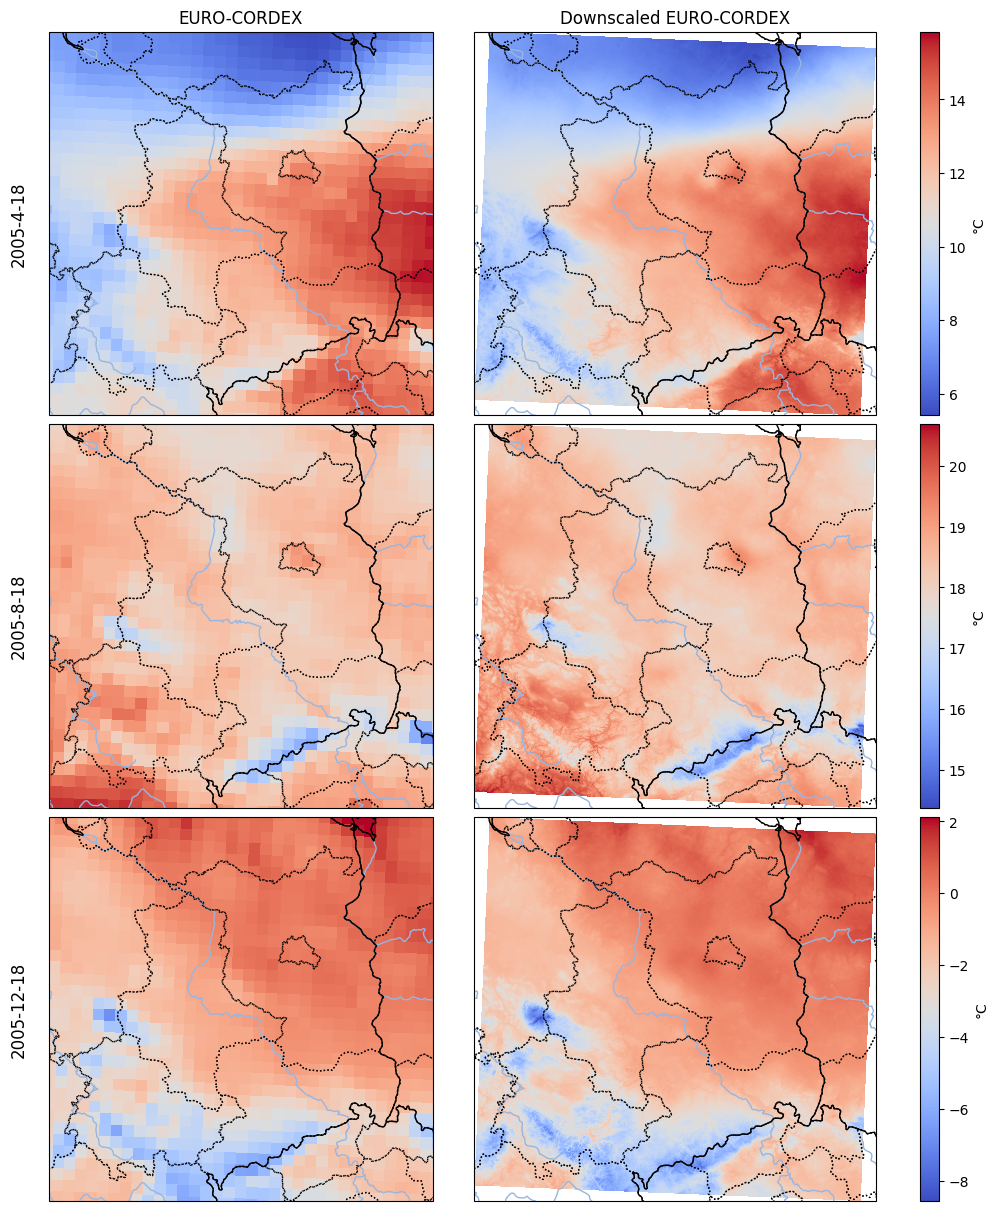

In [12]:
fig, axs = plt.subplots(ncols = 2, nrows = 3, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (10, 12), constrained_layout=True, rasterized=True)

date = '2005-12-18'

for i, date in enumerate(['2005-4-18', '2005-8-18', '2005-12-18']):
    cordex_in_rekis_region = cordex.sel(time=date, y = slice(bounds[3], bounds[1]), x = slice(bounds[0], bounds[2]))
    
    vmin = min(cordex_in_rekis_region.min().values, cordex_downscaled.sel(time=date).min().values)
    vmax = max(cordex_in_rekis_region.max().values, cordex_downscaled.sel(time=date).max().values)
    
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    
    im = cordex.sel(time=date).plot(
        ax=axs[i, 0],
        transform=cartopy.crs.epsg(31468),
        cmap="coolwarm",
        add_colorbar=False,
        norm=norm
    )
    
    axs[i, 0].set_extent(
        [bounds[0], bounds[2], bounds[1], bounds[3]],  # left, right, bottom, top
        crs=cartopy.crs.epsg(31468)
    )

    axs[i, 0].annotate(date, xy=(0, 0.5), xytext=(-15, 0),
                    xycoords='axes fraction', textcoords='offset points',
                    size='large', ha='right', va='center', rotation=90)
    
    cordex_downscaled.sel(time=date).plot(
        ax=axs[i, 1],
        transform=cartopy.crs.epsg(31468),
        cmap="coolwarm",
        add_colorbar=False,
        norm=norm
    )

    if i == 0:
        axs[i, 0].set_title('EURO-CORDEX')
        axs[i, 1].set_title('Downscaled EURO-CORDEX')
    else:
        axs[i, 0].set_title('')
        axs[i, 1].set_title('')

    fig.colorbar(im, ax=axs[i, :2], label='°C', location='right')

for i in range(6):
    ax = axs[i // 2, i % 2]
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES, linestyle=":")
    ax.add_feature(cartopy.feature.COASTLINE)

fig.savefig('images/downscaled_cordex.pdf', bbox_inches='tight', dpi=300)

plt.show()

Comparison of three different days in different seasons. The downscaled version appears sharper particularly in the mountainous region, however in April it also can make a smoother transition from colder to warmer region.

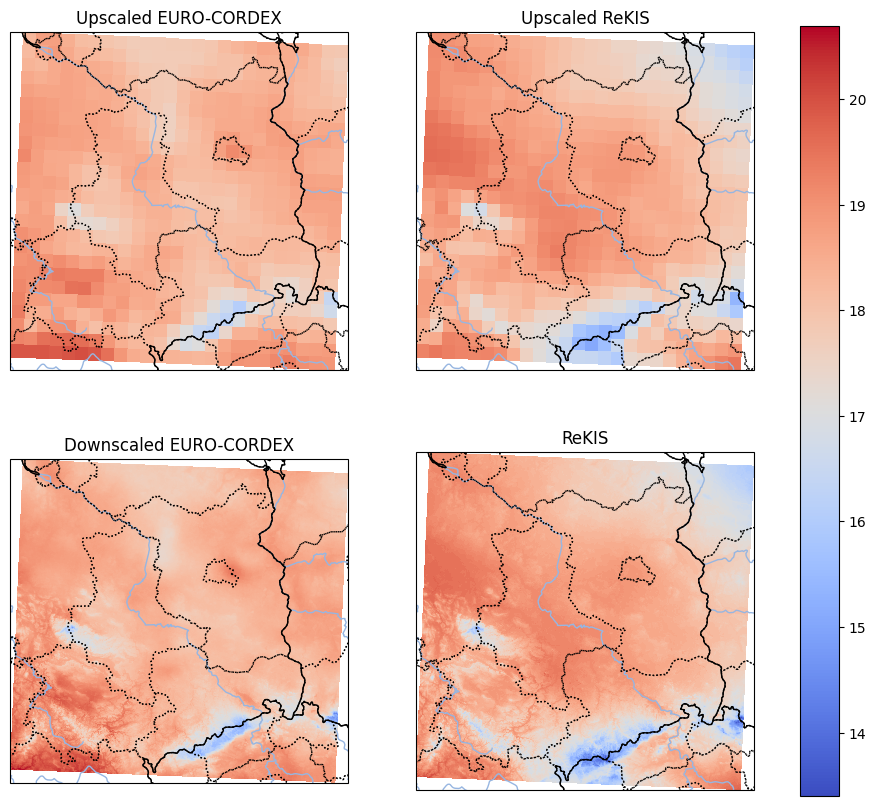

In [14]:
fig, axs = plt.subplots(ncols=2, nrows=2, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (12, 10))

vmin = min(cordex_reprojected_in_rekis_region.min().values,
           cordex_downscaled.sel(time=DATE).min().values,
           rekis.sel(time=DATE).min().values,
           rekis_upscaled.sel(time=DATE).min().values)
vmax = max(cordex_reprojected_in_rekis_region.max().values,
           cordex_downscaled.sel(time=DATE).max().values,
           rekis.sel(time=DATE).max().values,
           rekis_upscaled.sel(time=DATE).max().values)

norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

im = cordex_reprojected.sel(time=DATE).plot(
    ax=axs[0, 0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[0, 0].set_title('Upscaled EURO-CORDEX')

rekis_upscaled.sel(time=DATE).plot(
    ax=axs[0, 1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[0, 1].set_title('Upscaled ReKIS')

cordex_downscaled.sel(time=DATE).plot(
    ax=axs[1, 0],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1, 0].set_title('Downscaled EURO-CORDEX')

rekis.sel(time=DATE).plot(
    ax=axs[1, 1],
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=False,
    norm=norm
)

axs[1, 1].set_title('ReKIS')

fig.colorbar(im, ax = axs)

for i in range(2):
    for j in range(2):
        ax = axs[i, j]
        ax.add_feature(cartopy.feature.RIVERS)
        ax.add_feature(cartopy.feature.BORDERS)
        ax.add_feature(cartopy.feature.STATES, linestyle=":")
        ax.add_feature(cartopy.feature.COASTLINE)
plt.show()

EURO-CORDEX and ReKIS in the same LR and HR resolutions.